In [1]:
!pip install xgboost shap seaborn folium scipy tensorflow joblib scikit-learn pandas matplotlib

In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
files = glob.glob("*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (12042, 22)


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,Chennai,01/01/18,93.0,51.15,100.44,77.19,106.02,0.98,88.35,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chennai,02/01/18,100.0,55.00,108.00,83.00,114.00,1.05,95.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chennai,03/01/18,81.0,44.55,87.48,67.23,92.34,0.85,76.95,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Chennai,04/01/18,169.0,92.95,182.52,140.27,192.66,1.77,160.55,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Chennai,05/01/18,153.0,84.15,165.24,126.99,174.42,1.61,145.35,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

data = data.dropna()

data = data.sort_values("Date")

data.head()

/tmp/ipykernel_1304/2739563786.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'], errors='coerce')


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Chennai,2018-01-01,93.0,51.15,100.44,77.19,106.02,0.98,88.35
9486,Bangalore,2018-01-01,68.0,37.40,73.44,56.44,77.52,0.71,64.60
2551,Delhi,2018-01-01,406.0,223.30,438.48,336.98,462.84,4.26,385.70
4742,Hyderabad,2018-01-01,119.0,65.45,128.52,98.77,135.66,1.25,113.05
4773,Hyderabad,2018-01-02,117.0,64.35,126.36,97.11,133.38,1.23,111.15


In [5]:
def categorize_aqi(aqi):

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

data["AQI_Category"] = data["AQI"].apply(categorize_aqi)

In [6]:
from sklearn.preprocessing import LabelEncoder

city_encoder = LabelEncoder()
cat_encoder = LabelEncoder()

data["City"] = city_encoder.fit_transform(data["City"])
data["AQI_Category"] = cat_encoder.fit_transform(data["AQI_Category"])

In [7]:
features = [
    "City",
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]

X = data[features]
y = data["AQI_Category"]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

joblib.dump(scaler,"aqi_scaler.pkl")

['aqi_scaler.pkl']

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42
)

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[200,300],
    "max_depth":[4,6,8],
    "learning_rate":[0.05,0.1],
    "subsample":[0.8,1]
}

model = XGBClassifier(objective="multi:softmax")

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print("Best Params:",grid.best_params_)

Best Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [11]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

print(classification_report(y_test,y_pred))

Accuracy: 0.9983395599833956
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       639
           2       0.99      1.00      1.00       153
           3       1.00      1.00      1.00      1209
           4       1.00      0.87      0.93        23
           5       0.97      0.99      0.98        86

    accuracy                           1.00      2409
   macro avg       0.99      0.98      0.98      2409
weighted avg       1.00      1.00      1.00      2409



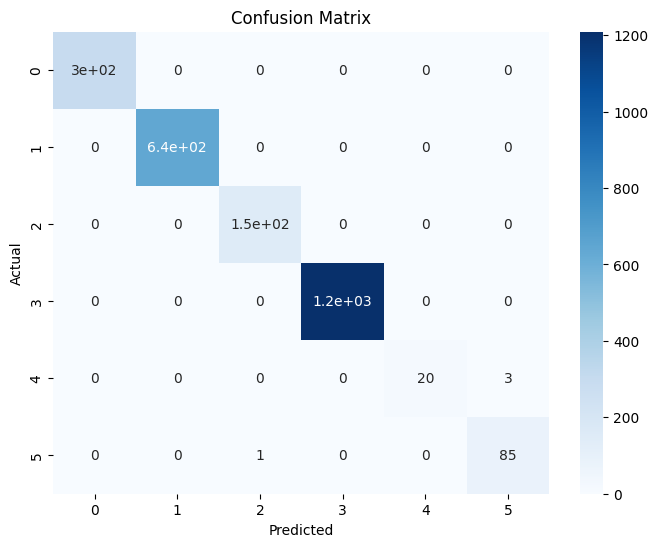

In [12]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

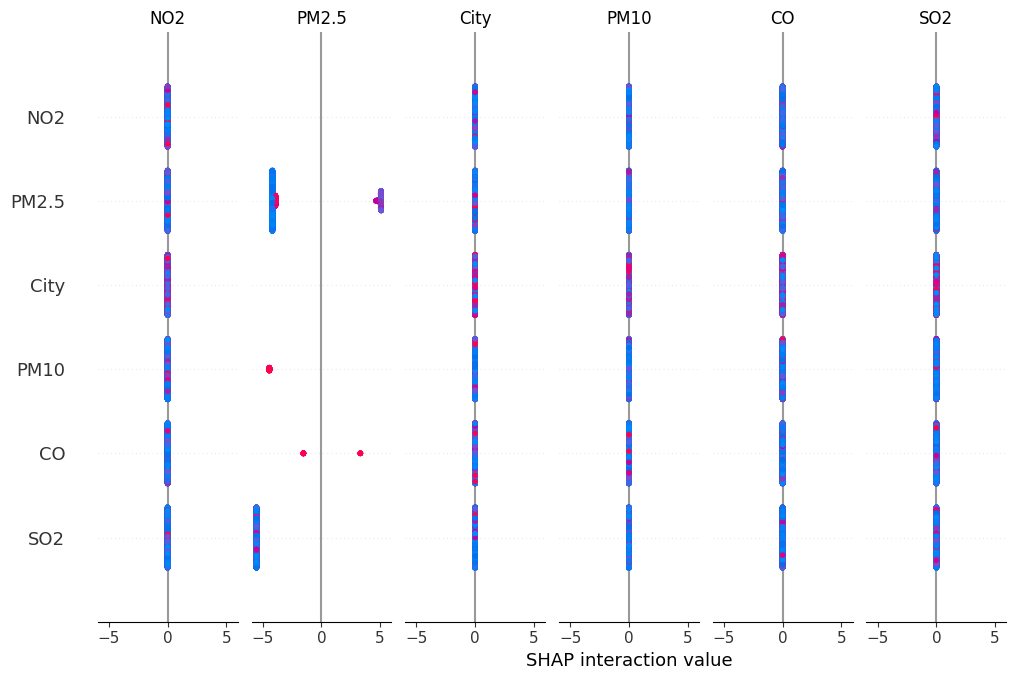

In [13]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values,X_test,feature_names=features)

In [14]:
joblib.dump(best_model,"ecothon_aqi_classifier.pkl")

['ecothon_aqi_classifier.pkl']

In [15]:
ts_features = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "AQI"
]

ts_data = data[ts_features]

from sklearn.preprocessing import MinMaxScaler

ts_scaler = MinMaxScaler()

scaled_data = ts_scaler.fit_transform(ts_data)

joblib.dump(ts_scaler,"aqi_timeseries_scaler.pkl")

['aqi_timeseries_scaler.pkl']

In [16]:
def create_sequences(data,seq_length=30):

    X=[]
    y=[]

    for i in range(len(data)-seq_length):

        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][-1])

    return np.array(X),np.array(y)

X_seq,y_seq = create_sequences(scaled_data)

In [17]:
from sklearn.model_selection import train_test_split

X_train_seq,X_test_seq,y_train_seq,y_test_seq = train_test_split(
    X_seq,y_seq,test_size=0.2,random_state=42
)

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Attention, Input, Flatten
from tensorflow.keras.models import Model

input_layer = Input(shape=(30,7))

lstm1 = LSTM(64,return_sequences=True)(input_layer)
lstm2 = LSTM(32,return_sequences=True)(lstm1)

attention = Attention()([lstm2,lstm2])

flat = Flatten()(attention)

dense = Dense(32,activation="relu")(flat)

output = Dense(1)(dense)

forecast_model = Model(inputs=input_layer,outputs=output)

forecast_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

forecast_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 64)    │     18,432 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 32)    │     12,416 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 30, 32)    │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 960)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │     30,752 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,633 (240.75 KB)

 Trainable params: 61,633 (240.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = forecast_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0266 - mae: 0.1120 - val_loss: 0.0218 - val_mae: 0.0969
Epoch 2/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0216 - mae: 0.1006 - val_loss: 0.0216 - val_mae: 0.0961
Epoch 3/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0232 - mae: 0.1056 - val_loss: 0.0214 - val_mae: 0.0972
Epoch 4/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0228 - mae: 0.1039 - val_loss: 0.0211 - val_mae: 0.0929
Epoch 5/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0230 - mae: 0.1032 - val_loss: 0.0208 - val_mae: 0.0972
Epoch 6/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0231 - mae: 0.1045 - val_loss: 0.0210 - val_mae: 0.1048
Epoch 7/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0214 - mae: 0.1001 - val_loss: 0.0205 - val_mae: 0.0943
Epoch 8/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0217 - mae: 0.1008 - val_loss: 0.0208 - val_mae: 0.1042
Epoch 9/30
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/ste

In [20]:
loss,mae = forecast_model.evaluate(X_test_seq,y_test_seq)

print("MAE:",mae)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0221 - mae: 0.0966
MAE: 0.0974683165550232


In [21]:
forecast_model.save("ecothon_aqi_forecast_model.h5")

In [22]:
city_coords = {
    "Bangalore":(12.9716,77.5946),
    "Chennai":(13.0827,80.2707),
    "Delhi":(28.7041,77.1025),
    "Hyderabad":(17.3850,78.4867),
    "Mumbai":(19.0760,72.8777)
}

coord_df = pd.DataFrame([
    {"City":k,"Lat":v[0],"Lon":v[1]} for k,v in city_coords.items()
])

predicted_aqi = pd.DataFrame({
    "City":["Bangalore","Chennai","Delhi","Hyderabad","Mumbai"],
    "Predicted_AQI":[120,95,210,140,180]
})

heatmap_data = predicted_aqi.merge(coord_df,on="City")

In [23]:
from scipy.interpolate import griddata

lat = heatmap_data["Lat"].values
lon = heatmap_data["Lon"].values
aqi = heatmap_data["Predicted_AQI"].values

grid_lat = np.linspace(min(lat)-1,max(lat)+1,100)
grid_lon = np.linspace(min(lon)-1,max(lon)+1,100)

grid_lon,grid_lat = np.meshgrid(grid_lon,grid_lat)

grid_aqi = griddata(
    (lat,lon),
    aqi,
    (grid_lat,grid_lon),
    method="cubic"
)

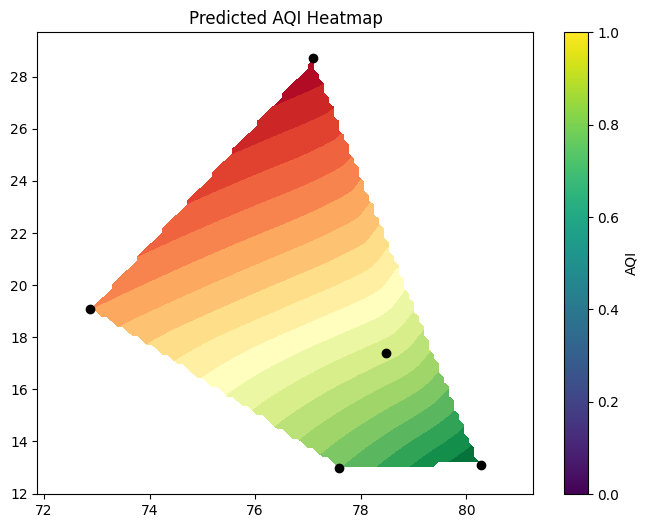

In [24]:
plt.figure(figsize=(8,6))

plt.contourf(grid_lon,grid_lat,grid_aqi,levels=20,cmap="RdYlGn_r")

plt.scatter(lon,lat,c="black")

plt.colorbar(label="AQI")

plt.title("Predicted AQI Heatmap")

plt.show()

In [25]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[22,78],zoom_start=5)

heat_data = [[row["Lat"],row["Lon"],row["Predicted_AQI"]]
             for _,row in heatmap_data.iterrows()]

HeatMap(heat_data).add_to(m)

m.save("ecothon_aqi_heatmap.html")

In [26]:
results = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

results.to_csv("ecothon_prediction_results.csv",index=False)

In [27]:
from google.colab import files

files.download("ecothon_aqi_classifier.pkl")
files.download("ecothon_aqi_forecast_model.h5")
files.download("aqi_scaler.pkl")
files.download("aqi_timeseries_scaler.pkl")
files.download("ecothon_prediction_results.csv")
files.download("ecothon_aqi_heatmap.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>